In [63]:
# Block 1: Loading combined data and initial cleaning
import pandas as pd
import numpy as np

# Load the combined data from the previous step
input_file = "processed_data/combined_raw_data.csv"
df = pd.read_csv(input_file)


# Deney sırasında kaydedilememiş veya boş kalmış veriler analiz dışı bırakılır
critical_columns = [
    'participant', 
    'age', 
    'handedness',      
    'gender',        
    'Gender',          # Yüzün cinsiyeti (Uyaran değişkeni)
    'Emotion',         
    'key_resp.rt', 
    'key_resp.corr']
df = df.dropna(subset=critical_columns)

print(f"Total trials after removing NaNs: {len(df)}")

Total trials after removing NaNs: 2160


In [64]:
# Block 2: Global Reaction Time Trimming
# 200 ms altındaki tepkiler genelde 'beklenti' veya 'yanlışlıkla basma' olarak kabul edilir.
# 3000 ms (3 saniye) üstündeki tepkiler ise katılımcının dikkat kaybını temsil eder.
lower_limit = 0.2
upper_limit = 3.0

# Filtreleme öncesi sayı
n_before_global = len(df)

df_filtered = df.query(f"{lower_limit} <= `key_resp.rt` <= {upper_limit}").copy()

# Filtreleme sonrası sayı
n_after_global = len(df_filtered)
n_removed_global = n_before_global - n_after_global
perc_removed_global = (n_removed_global / n_before_global) * 100


print(f"Global trimming ile silinen veri: {n_removed_global} deneme (Verinin %{perc_removed_global:.2f}'si)")
print(f"Kalan veri ({lower_limit}s - {upper_limit}s): {n_after_global}")

Global trimming ile silinen veri: 61 deneme (Verinin %2.82'si)
Kalan veri (0.2s - 3.0s): 2099


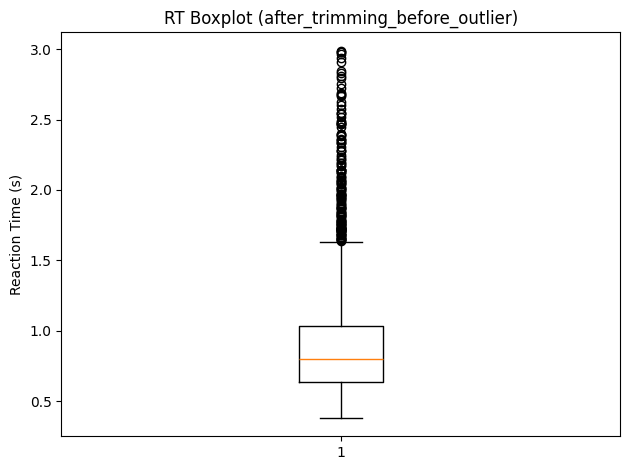

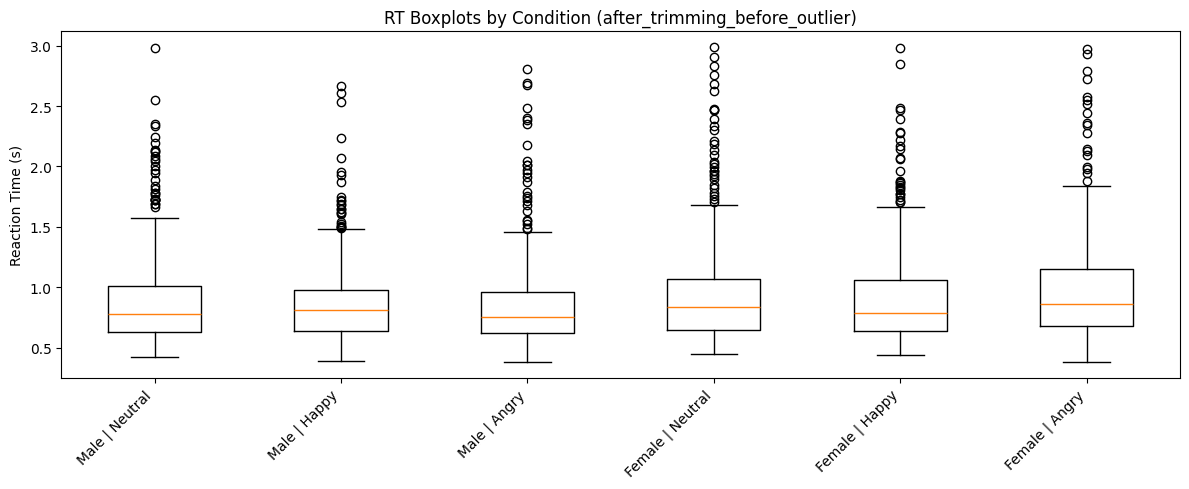

Boxplot çıktıları kaydedildi: processed_data\plots


In [65]:
# Blok 3: Boxplot (Outlier temizliği ÖNCESİ) - Trimming sonrası RT görselleştirme
# Amaç: Global trimming sonrası RT dağılımını ve olası aykırı değerleri boxplot ile göstermek

import matplotlib.pyplot as plt
import os

plots_folder = os.path.join("processed_data", "plots")
os.makedirs(plots_folder, exist_ok=True)

def plot_rt_boxplots(df_in, stage_tag):
    # RT analizi için sadece doğru yanıtları kullanıyoruz (standart yaklaşım)
    df_plot = df_in[df_in["key_resp.corr"] == 1].copy()

    # Sayısal olmayan RT değerlerine karşı güvenlik
    df_plot["key_resp.rt"] = pd.to_numeric(df_plot["key_resp.rt"], errors="coerce")
    df_plot = df_plot.dropna(subset=["key_resp.rt"])

    if df_plot.empty:
        print(f"[Plot Skip] RT verisi yok: {stage_tag}")
        return

    # 1) Genel RT boxplot
    plt.figure()
    plt.boxplot(df_plot["key_resp.rt"].values, vert=True)
    plt.ylabel("Reaction Time (s)")
    plt.title(f"RT Boxplot ({stage_tag})")
    plt.tight_layout()
    plt.savefig(os.path.join(plots_folder, f"boxplot_rt_overall_{stage_tag}.png"), dpi=300)
    plt.show()

    # 2) Koşullara göre RT boxplot (2x3: Gender x Emotion)
    df_plot["cond_label"] = df_plot[["Gender", "Emotion"]].astype(str).agg(" | ".join, axis=1)

    # Veride hangi etiketler varsa onları kullan (Male/Female yerine farklı etiketler olursa da çalışır)
    Genders = list(df_plot["Gender"].astype(str).unique())
    emotions = list(df_plot["Emotion"].astype(str).unique())

    # Eğer standart etiketler varsa, rapor okunabilirliği için sıralamayı sabitle
    preferred_genders = [g for g in ["Male", "Female"] if g in Genders] + [g for g in Genders if g not in ["Male", "Female"]]
    preferred_emotions = [e for e in ["Neutral", "Happy", "Angry"] if e in emotions] + [e for e in emotions if e not in ["Neutral", "Happy", "Angry"]]

    present_order = [f"{g} | {e}" for g in preferred_genders for e in preferred_emotions]

    data_to_plot = [
        df_plot.loc[df_plot["cond_label"] == lab, "key_resp.rt"].values
        for lab in present_order
    ]

    # Tüm koşullar boşsa çizme
    if all(len(arr) == 0 for arr in data_to_plot):
        print(f"[Plot Skip] Koşul bazlı RT verisi yok: {stage_tag}")
        return

    plt.figure(figsize=(12, 5))
    plt.boxplot(data_to_plot, tick_labels=present_order, vert=True)
    plt.xticks(rotation=45, ha="right")
    plt.ylabel("Reaction Time (s)")
    plt.title(f"RT Boxplots by Condition ({stage_tag})")
    plt.tight_layout()
    plt.savefig(os.path.join(plots_folder, f"boxplot_rt_by_condition_{stage_tag}.png"), dpi=300)
    plt.show()

    print(f"Boxplot çıktıları kaydedildi: {plots_folder}")

# Trimming sonrası / outlier öncesi
plot_rt_boxplots(df_filtered, stage_tag="after_trimming_before_outlier")


**NOT: Bu grafikler, global RT trimming (0.2–3.0 s) uygulandıktan sonra fakat ±2.5 SS Z-skor aykırı değer temizliği yapılmadan önceki tepki süresi (RT) dağılımlarını göstermektedir. İlk panel tüm doğru denemelerin genel RT dağılımını, ikinci panel ise koşullara göre (Uyaran Cinsiyeti × Duygu; 2×3) RT dağılımını sunar. RT dağılımlarının sağa çarpık (uzun kuyruklu) olması nedeniyle, boxplot üzerinde üst uçta çok sayıda nokta görülmesi beklenen bir durumdur.**

In [66]:
# Block 4: Within-Subject Outlier Removal using Z-Scores
# Her katılımcının kendi ortalamasından +/- 2.5 standart sapma uzaklıktaki verileri temizlenir.
# Bu işlem, bireysel hız farklarının analizi saptırmasını engellemek için yapılır.

# Gruplandırma kriterleri: Katılımcı, Yüzün Cinsiyeti ve Duygu Durumu
group_cols = ["participant", "Gender", "Emotion"]

# Filtreleme öncesi sayı
n_before_z = len(df_filtered)

# Z-skorlarını hesapla
z_scores = df_filtered.groupby(group_cols)["key_resp.rt"].transform(
    lambda x: (x - x.mean()) / x.std(ddof=1)
)

# Sadece Z-skoru -2.5 ile +2.5 arasında olanları tut
df_clean = df_filtered[z_scores.abs() <= 2.5].copy()

# Filtreleme sonrası sayı
n_after_z = len(df_clean)
n_removed_z = n_before_z - n_after_z
perc_removed_z = (n_removed_z / n_before_z) * 100
last_z = (1 - (n_after_z / n_before_global)) * 100


print(f"Z-skoru analizi ile silinen veri: {n_removed_z} deneme (Kalan verinin %{perc_removed_z:.2f}'si)")
print(f"Kalan veri: {n_after_z}")

print(f"Tüm temizlik işlemleri sonucu verinin %{last_z:.2f}'si silinmiştir.")

Z-skoru analizi ile silinen veri: 72 deneme (Kalan verinin %3.43'si)
Kalan veri: 2027
Tüm temizlik işlemleri sonucu verinin %6.16'si silinmiştir.


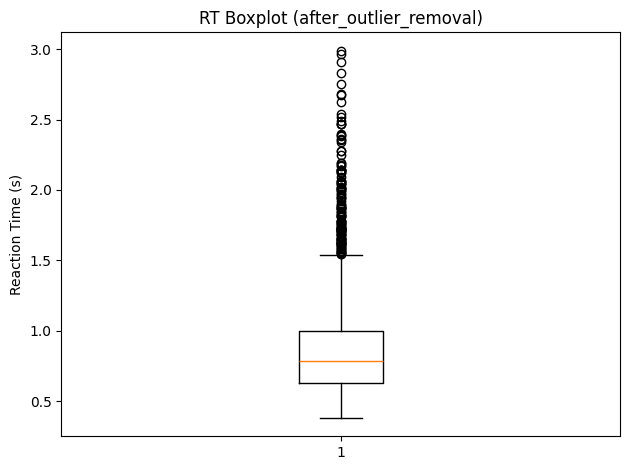

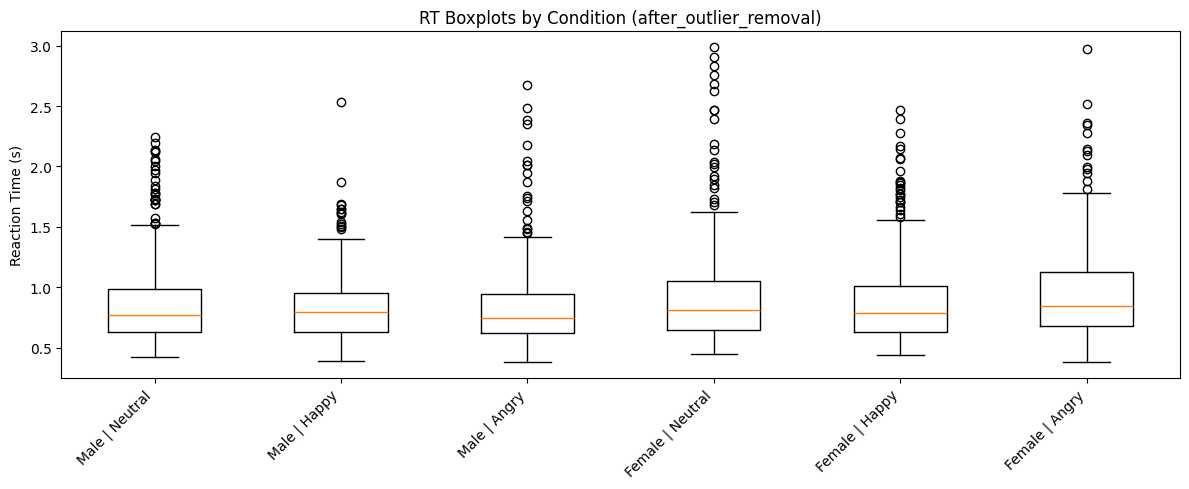

Boxplot çıktıları kaydedildi: processed_data\plots


In [ ]:
# Blok 5: Boxplot (Outlier temizliği SONRASI) - RT görselleştirme
# Amaç: Outlier temizliği öncesi/sonrası RT dağılımını karşılaştırmak

plot_rt_boxplots(df_clean, stage_tag="after_outlier_removal")


**NOT: Bu grafikler, trimming adımına ek olarak her katılımcı ve koşul içinde ±2.5 SS Z-skor kriteriyle aykırı RT değerleri çıkarıldıktan sonraki RT dağılımlarını göstermektedir. Outlier temizliği sonrası üst uçtaki aşırı değerlerin sayısında belirgin azalma gözlenmekte; buna karşın RT’nin doğası gereği sağa çarpık yapı tamamen ortadan kalkmamaktadır. Bu görselleştirme, aykırı değer temizliğinin dağılım üzerindeki etkisini (önce/sonra) doğrulamak amacıyla eklenmiştir.**

**Makul zaman aralığı ve doğruluk için standart sapma aralığı dikkate alınarak filtreleme yapılmıştır. Tüm verinin yüzde 6.16'sı aykırı olduğu için verisetinden çıkarılmıştır.**

In [68]:
# Block 6: Creating Summary Table for ANOVA
# RT analizi sadece doğru (correct) yanıtlar üzerinden yapılır.
# Accuracy (Doğruluk) ise tüm geçerli denemeler üzerinden hesaplanır.

# 1. Doğruluk Oranı (Accuracy) Hesaplama
accuracy_summary = df_clean.groupby(group_cols, as_index=False)['key_resp.corr'].mean()
accuracy_summary = accuracy_summary.rename(columns={'key_resp.corr': 'accuracy'})

# 2. Tepki Süresi (RT) Hesaplama (Sadece doğru yanıtlar için)
rt_summary = df_clean[df_clean['key_resp.corr'] == 1].groupby(group_cols, as_index=False)['key_resp.rt'].mean()
rt_summary = rt_summary.rename(columns={'key_resp.rt': 'mean_rt'})

# 3. İki özeti birleştirme
final_summary = accuracy_summary.merge(rt_summary, on=group_cols, how="left")

# Ek: Katılımcı demografilerini (gender, age, handedness) özet tabloya ekleme
participant_info = (
    df_clean[['participant', 'gender', 'age', 'handedness']]
    .drop_duplicates(subset=['participant'])
    .copy()
)

# İsim karışıklığını önlemek için katılımcı cinsiyetini daha açık isimle tutuyoruz
participant_info = participant_info.rename(columns={'gender': 'participant_gender'})

final_summary = final_summary.merge(participant_info, on='participant', how='left')



# Özet veriyi kaydetme
summary_save_path = "processed_data/final_summary_for_anova.csv"
final_summary.to_csv(summary_save_path, index=False)

print("Summary table created successfully.")
print(f"Dimensions of the final table (Subjects x Conditions): {final_summary.shape}")
display(final_summary.head(6)) # İlk katılımcının 6 koşulunu örnek olarak göster

Summary table created successfully.
Dimensions of the final table (Subjects x Conditions): (108, 8)


,participant,Gender,Emotion,accuracy,mean_rt,participant_gender,age,handedness
0,P01,Female,Angry,0.842105,0.749867,Male,23,Right
1,P01,Female,Happy,0.950000,0.764624,Male,23,Right
2,P01,Female,Neutral,0.894737,0.784127,Male,23,Right
3,P01,Male,Angry,0.900000,0.778184,Male,23,Right
4,P01,Male,Happy,1.000000,0.837710,Male,23,Right
5,P01,Male,Neutral,1.000000,0.769593,Male,23,Right


**NOT: RT analizi için sadece doğru yanıtları filtreledik.**